In [1]:
!pip uninstall pycaret -y
!pip install pycaret
!pip install optuna

Found existing installation: pycaret 3.3.2
Uninstalling pycaret-3.3.2:
  Successfully uninstalled pycaret-3.3.2
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
Using cached pycaret-3.3.2-py3-none-any.whl (486 kB)


In [2]:
import pandas as pd
import numpy as np
import ast
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import optuna
from sklearn.model_selection import learning_curve
from pycaret.regression import *

from pycaret.regression import get_config
from sklearn.impute import SimpleImputer

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path_data = '/content/drive/MyDrive/tesis_monica/afasia/data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# pycaret

In [4]:
# Cargar los splits
df_eng_train = pd.read_csv(path_data + 'df_eng_train.csv', encoding='utf-8')
df_eng_val = pd.read_csv(path_data + 'df_eng_val.csv', encoding='utf-8')
df_eng_test = pd.read_csv(path_data + 'df_eng_test.csv', encoding='utf-8')
df_external_test = pd.read_csv(path_data + 'df_external_test.csv', encoding='utf-8')


# quitas columnas
col_quitar = ["Inicio", "Fin", "TipusAfàsia", "NumId", "duracion", "Edat", "Gènere"]
df_eng_train = df_eng_train.drop(columns=col_quitar, errors='ignore')
df_eng_val = df_eng_val.drop(columns=col_quitar, errors='ignore')
df_eng_test = df_eng_test.drop(columns=col_quitar, errors='ignore')
df_external_test = df_external_test.drop(columns=col_quitar, errors='ignore')

# USE_EMBEDDINGSUnir train + val (para PyCaret, train debe incluir validación)
df_train_merged = pd.concat([df_eng_train, df_eng_val], ignore_index=True)

In [5]:
# 1) Procesar la columna 'bert_embedding' y eliminar filas sin embedding
def convert_embedding(x):
    """
    Convierte la columna 'bert_embedding' a una lista de floats (si está en JSON, str, etc.).
    Devuelve None si falla.
    """
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            try:
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return None
    elif isinstance(x, (list, np.ndarray)):
        return list(x)
    return None

for df_tmp in [df_eng_train, df_eng_val, df_eng_test, df_external_test]:
    df_tmp["bert_embedding"] = df_tmp["bert_embedding"].apply(convert_embedding)
    df_tmp.dropna(subset=["bert_embedding"], inplace=True)

In [6]:
# 2) Función para crear un DataFrame con o sin embeddingsdef make_feature_df(df_in, target_col='QA', use_embeddings=True):
def make_feature_df(df_in, target_col='QA', use_embeddings=True):
    """
    Crea un DataFrame para PyCaret:
      - Si use_embeddings=True, expande la columna 'bert_embedding' en columnas embedding_0, embedding_1, ...
      - Si use_embeddings=False, ignora la columna 'bert_embedding' y usa solo otras columnas numéricas.
    """
    # Convertir la columna 'bert_embedding' a listas (si no se ha hecho aún)
    df_in['bert_embedding'] = df_in['bert_embedding'].apply(convert_embedding)

    # Si vamos a usar embeddings, eliminamos filas que no tengan 'bert_embedding'
    if use_embeddings:
        df_in.dropna(subset=["bert_embedding"], inplace=True)

    # Extraer la columna objetivo como array
    y = df_in[target_col].astype(float).values

    if use_embeddings:
        # Expande la columna de embeddings
        X_array = np.vstack(df_in["bert_embedding"].values)  # shape: (num_samples, emb_dim)
        emb_dim = X_array.shape[1]
        emb_columns = [f"embedding_{i}" for i in range(emb_dim)]
        df_emb = pd.DataFrame(X_array, columns=emb_columns, index=df_in.index)

        # Otras columnas numéricas (excluyendo 'QA' y 'bert_embedding')
        numeric_cols = df_in.select_dtypes(include=['number']).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in ["QA", "bert_embedding"]]
        df_others = df_in[numeric_cols].copy()

        # Combinar: otras numéricas + embeddings
        df_out = pd.concat([df_others, df_emb], axis=1)
        df_out[target_col] = y

    else:
        # Ignoramos la columna 'bert_embedding'
        numeric_cols = df_in.select_dtypes(include=['number']).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in ["QA", "bert_embedding"]]

        df_out = df_in[numeric_cols].copy()
        df_out[target_col] = y

    return df_out

In [7]:
# 3) XXXX
USE_EMBEDDINGS = True # Cambia esta variable para usar (True) o ignorar (False) los embeddings

# Crear DataFrames para PyCaret según USE_EMBEDDINGS
df_train_merged_pycaret = make_feature_df(df_train_merged, target_col='QA', use_embeddings=USE_EMBEDDINGS)
df_test_pycaret = make_feature_df(df_eng_test, target_col='QA', use_embeddings=USE_EMBEDDINGS)
df_external_pycaret = make_feature_df(df_external_test, target_col='QA', use_embeddings=USE_EMBEDDINGS)

In [8]:
# 4) Configurar PyCaret
#    - Se le pasa todo el set train+val para que PyCaret haga su validación interna
#    - Por defecto, PyCaret hace 10-fold cross-validation, puedes ajustarlo.
#    - feature_selection=True activa la selección de características
#    - También se pueden ignorar columnas, pero aquí usamos todas las embedding_*

numeric_cols = [c for c in df_train_merged_pycaret.columns if c != 'QA']

reg_setup = setup(
    data=df_train_merged_pycaret,
    target='QA',
    session_id=42,
    fold=5,  # Cross-validation con 5 folds
    numeric_features=[col for col in df_train_merged_pycaret.columns if col.startswith('embedding_')],
    feature_selection=True,
    feature_selection_method='classic',
    feature_selection_estimator='lightgbm',
    normalize=True,
    transformation=True
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.268991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 226739
[LightGBM] [Info] Number of data points in the train set: 41438, number of used features: 893
[LightGBM] [Info] Start training from score 72.474379


,Description,Value
0,Session id,42
1,Target,QA
2,Target type,Regression
3,Original data shape,"(59198, 895)"
4,Transformed data shape,"(59198, 179)"
5,Transformed train set shape,"(41438, 179)"
6,Transformed test set shape,"(17760, 179)"
7,Numeric features,768
8,Rows with missing values,0.0%
9,Preprocess,True


In [9]:
# 5) Comparar modelos y seleccionar el mejor (según MAE)
best_model = compare_models(sort='MAE')
print("Mejor modelo según PyCaret:", best_model)

# Identificamos el tipo (clase) del modelo
model_name = type(best_model).__name__
print("Tipo de modelo:", model_name)

# 6) Hacer Tuning de ese "best_model"
# Definimos grids separados, según la clase del modelo
# ----------------------------------------------------
knn_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

tree_grid = {  # Para RandomForestRegressor o ExtraTreesRegressor
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    # 'min_samples_split': [2, 5, 10],  # puedes añadir más
}

boost_grid = {  # Para XGBoost, LightGBM, GradientBoostingRegressor
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Según el modelo, escogemos la rejilla adecuada (o ninguna)
# ----------------------------------------------------------
if "KNeighborsRegressor" in model_name:
    print("Voy a tunear KNN con parámetros de knn_grid.")
    chosen_grid = knn_grid
elif "RandomForestRegressor" in model_name or "ExtraTreesRegressor" in model_name:
    print("Voy a tunear un modelo de árboles (RF o ET).")
    chosen_grid = tree_grid
elif "XGBRegressor" in model_name or "LGBMRegressor" in model_name or "GradientBoostingRegressor" in model_name:
    print("Voy a tunear un modelo de boosting (XGB, LightGBM o GBR).")
    chosen_grid = boost_grid
else:
    print("Modelo sin custom grid específico. Usaré tune_model() sin custom_grid.")
    chosen_grid = None

# Invocamos tune_model con la rejilla apropiada, si existe
# --------------------------------------------------------
if chosen_grid is not None:
    tuned_best_model = tune_model(
        best_model,
        optimize='MAE',
        n_iter=5,
        custom_grid=chosen_grid
    )
else:
    tuned_best_model = tune_model(
        best_model,
        optimize='MAE',
        n_iter=5
    )

print("Mejor modelo (ya afinado):", tuned_best_model)

# 7) Convertirlo en tu modelo final
final_model = finalize_model(tuned_best_model)

# 8) Evaluar en test interno y test externo
predictions_test = predict_model(final_model, data=df_test_pycaret)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
xgboost,Extreme Gradient Boosting,10.6847,197.1081,14.0393,0.3957,0.2541,0.1977,70.7720
lightgbm,Light Gradient Boosting Machine,11.1253,204.2353,14.2907,0.3739,0.2593,0.2082,212.1540
rf,Random Forest Regressor,11.8348,227.0667,15.0684,0.3038,0.2719,0.2224,254.7680
dummy,Dummy Regressor,14.4910,326.3299,18.0637,-0.0003,0.3215,0.2818,71.9580
dt,Decision Tree Regressor,16.0049,478.7480,21.8802,-0.4682,0.3848,0.2813,80.4380


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

Mejor modelo según PyCaret: XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)
Tipo de modelo: XGBRegressor
Voy a tunear un modelo de boosting (XGB, LightGBM o GBR).


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,9.7868,171.3286,13.0893,0.4790,0.2451,0.1874
1,9.7182,166.3160,12.8964,0.4730,0.2310,0.1762
2,9.7789,171.8970,13.1109,0.4676,0.2418,0.1842
3,9.8255,170.4643,13.0562,0.4844,0.2453,0.1870
4,9.8761,171.1001,13.0805,0.4865,0.2408,0.1858
Mean,9.7971,170.2212,13.0467,0.4781,0.2408,0.1841
Std,0.0523,2.0058,0.0772,0.0070,0.0052,0.0041


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Mejor modelo (ya afinado): XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=7, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,10.1486,173.3262,13.1653,0.4640,0.2247,0.1766


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,10.1486,173.3262,13.1653,0.4640,0.2247,0.1766



Test Interno: MAE = 10.15, R2 = 0.46


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extreme Gradient Boosting,14.4483,343.1322,18.5238,-0.0458,0.3055,0.2674


Test Externo: MAE = 14.45, R2 = -0.05


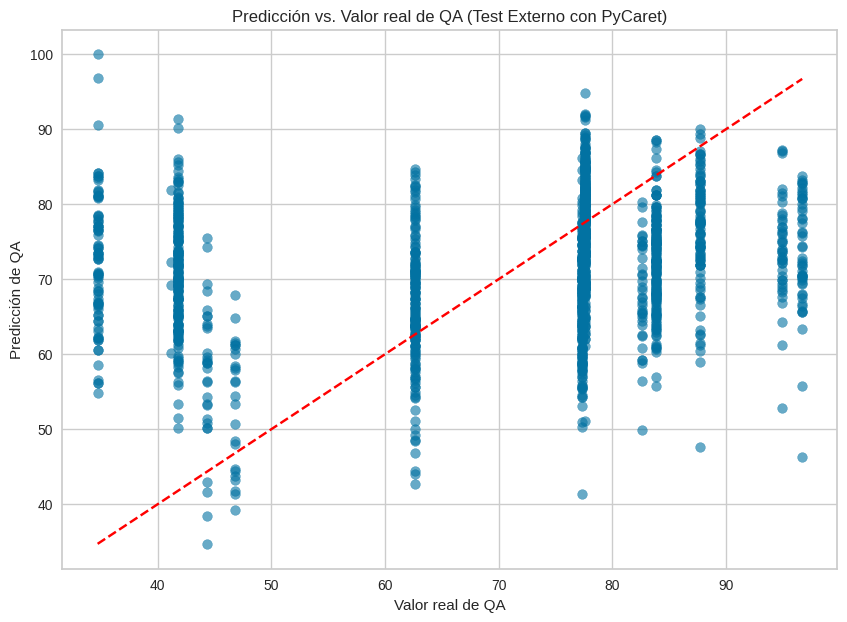

In [10]:
# 7) Evaluar en test interno y test externo

# Test interno
predictions_test = predict_model(final_model, data=df_test_pycaret)
y_true_test = predictions_test['QA']
y_pred_test = predictions_test['prediction_label']

mae_test = mean_absolute_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"\nTest Interno: MAE = {mae_test:.2f}, R2 = {r2_test:.2f}")

# Test externo
predictions_external = predict_model(final_model, data=df_external_pycaret)
y_true_ext = predictions_external['QA']
y_pred_ext = predictions_external['prediction_label']

mae_ext = mean_absolute_error(y_true_ext, y_pred_ext)
r2_ext = r2_score(y_true_ext, y_pred_ext)
print(f"Test Externo: MAE = {mae_ext:.2f}, R2 = {r2_ext:.2f}")

# Visualizar predicción vs. valor real en test externo
plt.figure(figsize=(10, 7))
plt.scatter(y_true_ext, y_pred_ext, alpha=0.6)
plt.plot([y_true_ext.min(), y_true_ext.max()], [y_true_ext.min(), y_true_ext.max()], '--', color='red')
plt.xlabel("Valor real de QA")
plt.ylabel("Predicción de QA")
plt.title("Predicción vs. Valor real de QA (Test Externo con PyCaret)")
plt.show()

Modelo final: XGBRegressor


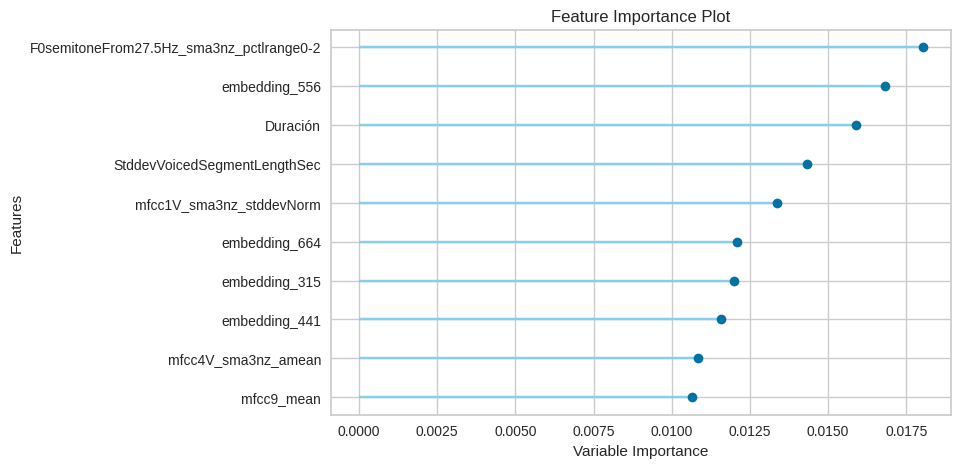

Advertencia: la cantidad de importancias no coincide con los nombres de features.


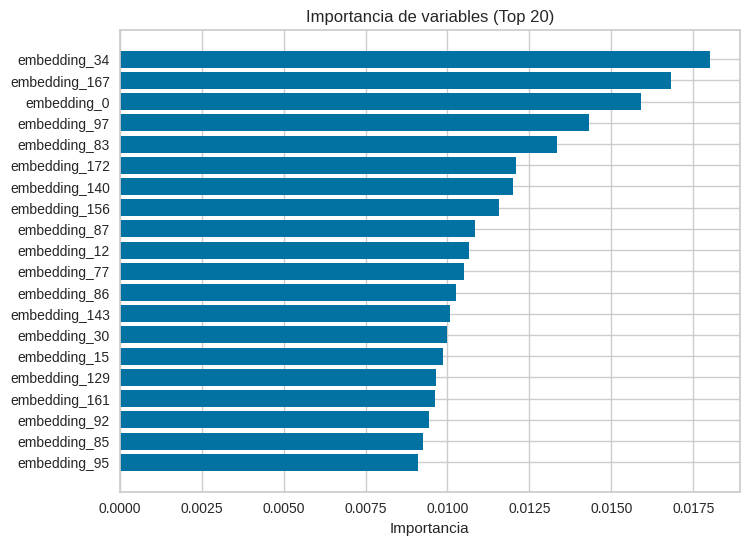

In [11]:
# 8) Visualización de la importancia de variables

# 8.1) Verificar si el modelo tiene coef_ o feature_importances_
#     antes de usar plot_model(final_model, plot='feature')
model_type = type(final_model.named_steps['actual_estimator']).__name__
print("Modelo final:", model_type)

if hasattr(final_model.named_steps['actual_estimator'], 'feature_importances_') \
   or hasattr(final_model.named_steps['actual_estimator'], 'coef_'):
    # Usamos la función de PyCaret para visualizar importancia
    plot_model(final_model, plot='feature')
else:
    print(f"El modelo {model_type} no soporta 'feature_importances_' ni 'coef_'. Se omite plot_model.")

# 8.2) Función personalizada para graficar importancia de variables
def plot_feature_importance(model, feature_names):
    """
    Dibuja la importancia de variables de forma distinta según si el modelo
    es lineal (atributo .coef_) o de árbol (atributo .feature_importances_).
    """
    import matplotlib.pyplot as plt
    import pandas as pd

    if hasattr(model, 'coef_'):
        coefs = model.coef_
        if len(coefs.shape) > 1:
            coefs = coefs[0]

        if len(coefs) != len(feature_names):
            print("Advertencia: la cantidad de coeficientes no coincide con los nombres de features.")
            feature_names = feature_names[:len(coefs)]

        df_coefs = pd.DataFrame({
            'feature': feature_names,
            'coef': coefs
        })

        df_coefs['abs_coef'] = df_coefs['coef'].abs()
        df_coefs = df_coefs.sort_values('abs_coef', ascending=False)

        top_20 = df_coefs.head(20)

        plt.figure(figsize=(8, 6))
        plt.barh(top_20['feature'], top_20['coef'])
        plt.gca().invert_yaxis()
        plt.title('Coeficientes del modelo (Top 20)')
        plt.xlabel('Valor del coeficiente')
        plt.show()

    elif hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        if len(importances) != len(feature_names):
            print("Advertencia: la cantidad de importancias no coincide con los nombres de features.")
            feature_names = feature_names[:len(importances)]

        df_importances = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })

        df_importances = df_importances.sort_values('importance', ascending=False)
        top_20 = df_importances.head(20)

        plt.figure(figsize=(8, 6))
        plt.barh(top_20['feature'], top_20['importance'])
        plt.gca().invert_yaxis()
        plt.title('Importancia de variables (Top 20)')
        plt.xlabel('Importancia')
        plt.show()

    else:
        print("Este modelo no tiene ni 'coef_' ni 'feature_importances_'. Usa otras formas de interpretación.")

# 8.3) Ejecutar función personalizada si el modelo lo permite
actual_model = final_model.named_steps['actual_estimator']
feature_names = [col for col in df_train_merged_pycaret.columns if col.startswith('embedding_')]

if hasattr(actual_model, 'coef_') or hasattr(actual_model, 'feature_importances_'):
    plot_feature_importance(actual_model, feature_names)
else:
    print(f"El modelo {model_type} no tiene atributos de importancia de variables. Se omite 'plot_feature_importance'.")

      Grup        MAE         R2  Count
0     Mild  13.188935  -4.864296  574.0
1   Severe  28.419138 -66.920825  323.0
2  Unknown   6.227738  -0.215087  461.0


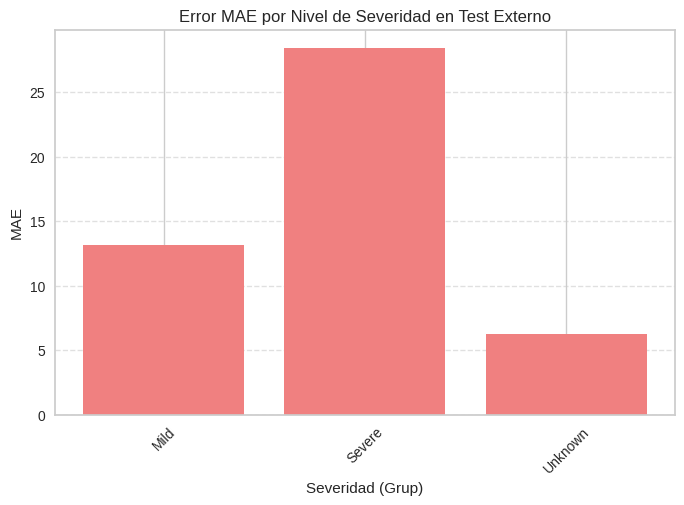

In [12]:
# 12) Evaluar el Error por Severidad (Grup)
df_external_results = df_external_test.copy()
df_external_results["QA_pred"] = predictions_external["prediction_label"]

df_errors = df_external_results.groupby("Grup").apply(
    lambda g: pd.Series({
        "MAE": mean_absolute_error(g["QA"], g["QA_pred"]),
        "R2": r2_score(g["QA"], g["QA_pred"]),
        "Count": len(g)
    })
).reset_index()

# Mostrar tabla de errores por severidad
print(df_errors)

# 13) Graficar el Error por Severidad
plt.figure(figsize=(8, 5))
plt.bar(df_errors["Grup"], df_errors["MAE"], color="lightcoral")
plt.xlabel("Severidad (Grup)")
plt.ylabel("MAE")
plt.title("Error MAE por Nivel de Severidad en Test Externo")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Cantidad de valores NaN en X_train: 88


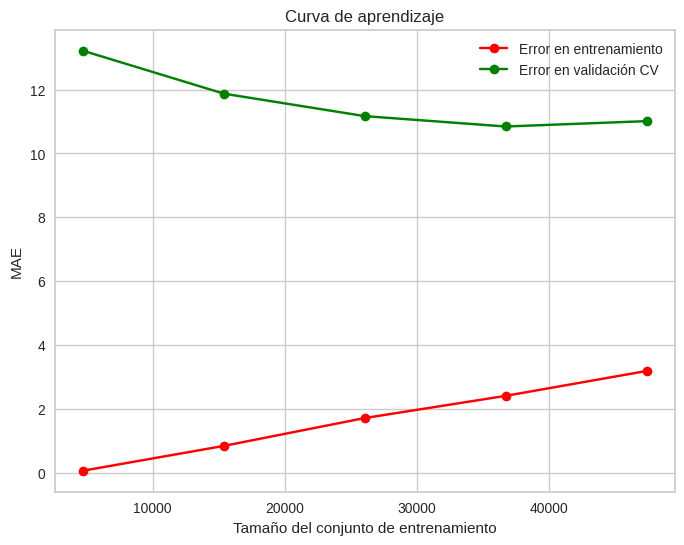

In [13]:
from sklearn.impute import SimpleImputer

def plot_learning_curve(model, X, y, scoring='neg_mean_absolute_error', cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='red', label='Error en entrenamiento')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Error en validación CV')
    plt.title("Curva de aprendizaje")
    plt.xlabel("Tamaño del conjunto de entrenamiento")
    plt.ylabel("MAE")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Extraer datos para la curva de aprendizaje
X_train = df_train_merged_pycaret.drop(columns=['QA'])
y_train = df_train_merged_pycaret['QA']

# Verificar NaN
print(f"Cantidad de valores NaN en X_train: {X_train.isna().sum().sum()}")

# Imputar NaN con la mediana
imputer = SimpleImputer(strategy="median")
X_train_clean = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
y_train_clean = y_train.copy()

# Extraer el modelo subyacente de la pipeline de PyCaret
underlying_model = final_model.named_steps['actual_estimator']

# Graficar la curva de aprendizaje
plot_learning_curve(underlying_model, X_train_clean, y_train_clean, scoring='neg_mean_absolute_error', cv=5)

# Lightgbm

In [4]:
import pandas as pd
import numpy as np
import json
import ast
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna
import shap
from scipy.stats import spearmanr

In [5]:
# 1) CARGAR LOS SPLITS PREDEFINIDOS
df_eng_train = pd.read_csv(path_data + "df_eng_train.csv", encoding="utf-8")
df_eng_val = pd.read_csv(path_data + "df_eng_val.csv", encoding="utf-8")
df_eng_test = pd.read_csv(path_data + "df_eng_test.csv", encoding="utf-8")
df_external_test = pd.read_csv(path_data + "df_external_test.csv", encoding="utf-8")

In [6]:
# 2) ELIMINAR COLUMNAS IRRELEVANTES
col_quitar = ["Inicio", "Fin", "TipusAfàsia", "NumId", "duracion", "Edat", "Gènere", 'Grup', 'fluency_speech', 'aphasia_type']
for df_tmp in [df_eng_train, df_eng_val, df_eng_test, df_external_test]:
    df_tmp.drop(columns=col_quitar, errors='ignore', inplace=True)

In [7]:
# 3) PROCESAR LA COLUMNA 'bert_embedding'
def convert_embedding(x):
    if isinstance(x, str):
        try:
            return json.loads(x)
        except json.JSONDecodeError:
            try:
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return None
    elif isinstance(x, (list, np.ndarray)):
        return list(x)
    return None

for df_tmp in [df_eng_train, df_eng_val, df_eng_test, df_external_test]:
    df_tmp["bert_embedding"] = df_tmp["bert_embedding"].apply(convert_embedding)
    df_tmp.dropna(subset=["bert_embedding"], inplace=True)

In [8]:
# 4) FUNCIÓN PARA CREAR X, Y (expandiendo embeddings si deseas)
def make_feature_df(df_in, target_col="QA", use_embeddings=True):
    df_in["bert_embedding"] = df_in["bert_embedding"].apply(convert_embedding)

    if use_embeddings:
        df_in.dropna(subset=["bert_embedding"], inplace=True)

    y = df_in[target_col].astype(float).values

    if use_embeddings:
        # Expandir embeddings
        X_array = np.vstack(df_in["bert_embedding"].values)
        emb_dim = X_array.shape[1]
        emb_columns = [f"embedding_{i}" for i in range(emb_dim)]
        df_emb = pd.DataFrame(X_array, columns=emb_columns, index=df_in.index)

        # Otras columnas numéricas
        numeric_cols = df_in.select_dtypes(include=['number']).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in [target_col, "bert_embedding"]]
        df_others = df_in[numeric_cols].copy()

        df_out = pd.concat([df_others, df_emb], axis=1)
        df_out[target_col] = y
    else:
        numeric_cols = df_in.select_dtypes(include=['number']).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in [target_col, "bert_embedding"]]
        df_out = df_in[numeric_cols].copy()
        df_out[target_col] = y

    return df_out


USE_EMBEDDINGS = True

df_train = make_feature_df(df_eng_train, target_col="QA", use_embeddings=USE_EMBEDDINGS)
df_val   = make_feature_df(df_eng_val,   target_col="QA", use_embeddings=USE_EMBEDDINGS)
df_test  = make_feature_df(df_eng_test,  target_col="QA", use_embeddings=USE_EMBEDDINGS)
df_ext   = make_feature_df(df_external_test,  target_col="QA", use_embeddings=USE_EMBEDDINGS)

In [9]:

# 5) OBTENER X, Y PARA CADA SPLIT (sin mezclarlos)
X_train = df_train.drop(columns=["QA"])
y_train = df_train["QA"]

X_val = df_val.drop(columns=["QA"])
y_val = df_val["QA"]

X_test = df_test.drop(columns=["QA"])
y_test = df_test["QA"]

X_ext = df_ext.drop(columns=["QA"])
y_ext = df_ext["QA"]

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test interno:", X_test.shape, y_test.shape)
print("Test externo:", X_ext.shape, y_ext.shape)

Shapes:
Train: (48536, 894) (48536,)
Val: (10662, 894) (10662,)
Test interno: (10663, 894) (10663,)
Test externo: (1358, 894) (1358,)


In [10]:
# 5) PRIMER ENTRENAMIENTO: ALL FEATURES + OPTUNA
pipeline_all = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("lgbm",    LGBMRegressor(random_state=42, verbose=-1))
])

# Para la optimización, usaremos SOLO X_train, y_train
# y (opcionalmente) podemos reentrenar con train+val luego.
def objective_all(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 2000, step=200)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.1, log=True)
    num_leaves = trial.suggest_int("num_leaves", 31, 255, step=32)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100, step=5),

    pipeline_all.set_params(
        lgbm__n_estimators=n_estimators,
        lgbm__max_depth=max_depth,
        lgbm__learning_rate=learning_rate,
        lgbm__num_leaves=num_leaves,
        lgbm__reg_alpha=reg_alpha,
        lgbm__reg_lambda=reg_lambda,
        lgbm__min_child_samples=min_child_samples
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline_all, X_train, y_train,
        cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    mae_cv = -np.mean(scores)
    return mae_cv

study_all = optuna.create_study(direction="minimize")
study_all.optimize(objective_all, n_trials=2, show_progress_bar=True)  # Ajusta n_trials

best_params_all = study_all.best_params
print("=== Best MAE (ALL features) ===", study_all.best_value)
print("=== Best params (ALL features) ===", best_params_all)

[I 2025-04-01 07:24:47,867] A new study created in memory with name: no-name-383f42df-4175-4030-b183-5ed2db3bf179


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2025-04-01 08:58:53,291] Trial 0 finished with value: 10.225764846619347 and parameters: {'n_estimators': 1600, 'max_depth': 7, 'learning_rate': 0.006871598352027068, 'num_leaves': 159, 'reg_alpha': 0.07225786440127253, 'reg_lambda': 2.563530505316838, 'min_child_samples': 85}. Best is trial 0 with value: 10.225764846619347.
[I 2025-04-01 09:22:18,062] Trial 1 finished with value: 12.12060380327517 and parameters: {'n_estimators': 800, 'max_depth': 5, 'learning_rate': 0.004628991679445601, 'num_leaves': 255, 'reg_alpha': 0.036300103995042764, 'reg_lambda': 9.993128876660487e-06, 'min_child_samples': 90}. Best is trial 0 with value: 10.225764846619347.
=== Best MAE (ALL features) === 10.225764846619347
=== Best params (ALL features) === {'n_estimators': 1600, 'max_depth': 7, 'learning_rate': 0.006871598352027068, 'num_leaves': 159, 'reg_alpha': 0.07225786440127253, 'reg_lambda': 2.563530505316838, 'min_child_samples': 85}


In [11]:
# Entrenar pipeline_all con best_params
pipeline_all.set_params(
    lgbm__n_estimators=best_params_all["n_estimators"],
    lgbm__max_depth=best_params_all["max_depth"],
    lgbm__learning_rate=best_params_all["learning_rate"],
    lgbm__num_leaves=best_params_all["num_leaves"],
    lgbm__reg_alpha=best_params_all["reg_alpha"],
    lgbm__reg_lambda=best_params_all["reg_lambda"],
    lgbm__min_child_samples=best_params_all["min_child_samples"]
)

# Entrenar en train
pipeline_all.fit(X_train, y_train)

# Opcional: reentrenar con (train+val)
RETRAIN_WITH_VAL = True
if RETRAIN_WITH_VAL:
    X_train_val = pd.concat([X_train, X_val], axis=0)
    y_train_val = pd.concat([y_train, y_val], axis=0)
    pipeline_all.fit(X_train_val, y_train_val)
    print("Modelo ALL reentrenado con train+val")

# Evaluar en test interno
y_pred_test_all = pipeline_all.predict(X_test)
mae_test_all = mean_absolute_error(y_test, y_pred_test_all)
r2_test_all  = r2_score(y_test, y_pred_test_all)
print(f"[TEST INTERNO - ALL] MAE={mae_test_all:.2f}, R2={r2_test_all:.2f}")

# Evaluar en test externo
y_pred_ext_all = pipeline_all.predict(X_ext)
mae_ext_all = mean_absolute_error(y_ext, y_pred_ext_all)
r2_ext_all  = r2_score(y_ext, y_pred_ext_all)
print(f"[TEST EXTERNO - ALL] MAE={mae_ext_all:.2f}, R2={r2_ext_all:.2f}")

Modelo ALL reentrenado con train+val
[TEST INTERNO - ALL] MAE=11.65, R2=0.35
[TEST EXTERNO - ALL] MAE=12.63, R2=0.22



=== TOP 20 IMPORTANCIA (ALL features) ===
                                        feature  importance
46                 loudness_sma3_percentile20.0        2567
20                                  mfcc13_mean        2357
17                                  mfcc10_mean        2257
112                   slopeUV0-500_sma3nz_amean        1938
13                                   mfcc6_mean        1703
18                                  mfcc11_mean        1659
19                                  mfcc12_mean        1620
15                                   mfcc8_mean        1607
36   F0semitoneFrom27.5Hz_sma3nz_percentile20.0        1599
16                                   mfcc9_mean        1586
37   F0semitoneFrom27.5Hz_sma3nz_percentile50.0        1370
14                                   mfcc7_mean        1325
110                   alphaRatioUV_sma3nz_amean        1240
100                  spectralFluxV_sma3nz_amean        1233
124                             amplitud_minima        10

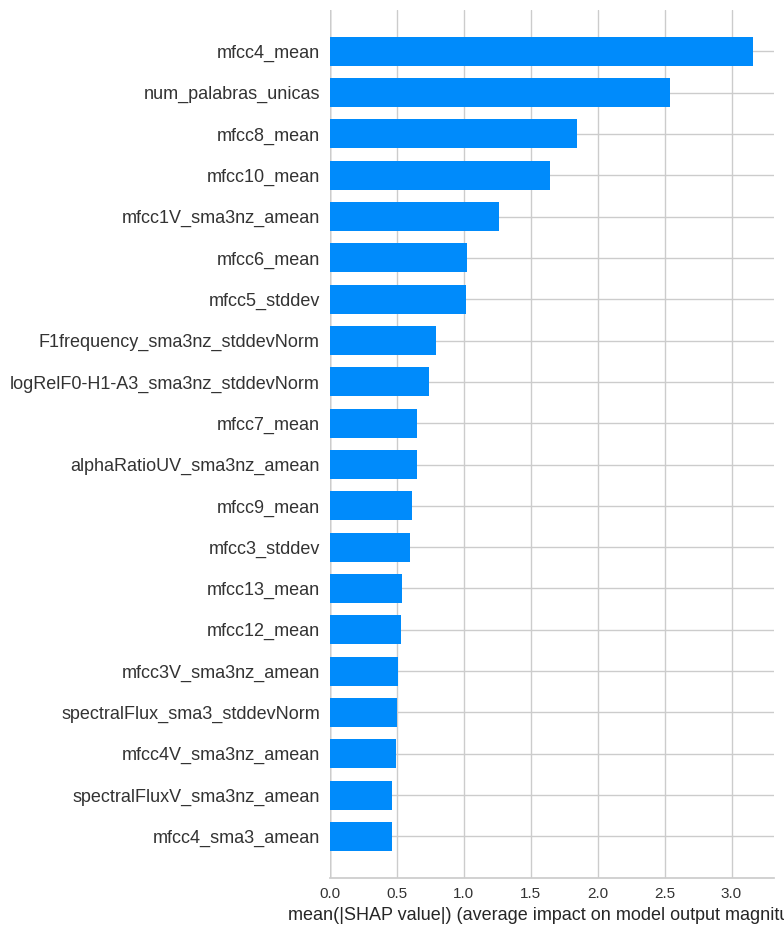

In [12]:
# 6) IMPORTANCIA DE VARIABLES (SHAP + feature_importances_)
lgbm_all = pipeline_all.named_steps["lgbm"]

# Feature importances nativa
if hasattr(lgbm_all, "feature_importances_"):
    importances_all = lgbm_all.feature_importances_
    features_all    = X_train.columns
    df_imp_all = pd.DataFrame({"feature": features_all, "importance": importances_all})
    df_imp_all.sort_values("importance", ascending=False, inplace=True)
    print("\n=== TOP 20 IMPORTANCIA (ALL features) ===")
    print(df_imp_all.head(20))

# SHAP
explainer_all = shap.TreeExplainer(lgbm_all)
X_sample_all = X_train_val.iloc[:500] if RETRAIN_WITH_VAL else X_train.iloc[:500]
shap_values_all = explainer_all.shap_values(X_sample_all)

shap.summary_plot(shap_values_all, X_sample_all, plot_type="bar", show=True)

In [13]:
# 7) SELECCIONAR TOP K FEATURES

K = 50
df_imp_topK = df_imp_all.head(K)
top_features = df_imp_topK["feature"].tolist()
print(f"\nSeleccionamos top {K} features: {top_features[:10]} ...")

def filter_df(df_in, keep_list, target_col="QA"):
    return df_in[[c for c in df_in.columns if c in keep_list or c==target_col]].copy()

df_train_top = filter_df(df_train, top_features)
df_val_top   = filter_df(df_val,   top_features)
df_test_top  = filter_df(df_test,  top_features)
df_ext_top   = filter_df(df_ext,   top_features)

X_train_top = df_train_top.drop(columns=["QA"])
y_train_top = df_train_top["QA"]
X_val_top   = df_val_top.drop(columns=["QA"])
y_val_top   = df_val_top["QA"]
X_test_top  = df_test_top.drop(columns=["QA"])
y_test_top  = df_test_top["QA"]
X_ext_top   = df_ext_top.drop(columns=["QA"])
y_ext_top   = df_ext_top["QA"]


Seleccionamos top 50 features: ['loudness_sma3_percentile20.0', 'mfcc13_mean', 'mfcc10_mean', 'slopeUV0-500_sma3nz_amean', 'mfcc6_mean', 'mfcc11_mean', 'mfcc12_mean', 'mfcc8_mean', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'mfcc9_mean'] ...


In [14]:
# 8) ENTRENAR DE NUEVO + OPTUNA PERO SOLO CON TOP K
pipeline_top = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("lgbm",    LGBMRegressor(random_state=42, verbose=-1))
])

def objective_top(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 2000, step=200)
    max_depth = trial.suggest_int("max_depth", 3, 12)
    learning_rate = trial.suggest_float("learning_rate", 1e-3, 0.1, log=True)
    num_leaves = trial.suggest_int("num_leaves", 31, 255, step=32)
    reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    min_child_samples = trial.suggest_int("min_child_samples", 5, 100, step=5),

    pipeline_top.set_params(
        lgbm__n_estimators=n_estimators,
        lgbm__max_depth=max_depth,
        lgbm__learning_rate=learning_rate,
        lgbm__num_leaves=num_leaves,
        lgbm__reg_alpha=reg_alpha,
        lgbm__reg_lambda=reg_lambda,
        lgbm__min_child_samples=min_child_samples
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipeline_top, X_train_top, y_train_top,
        cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    mae_cv = -np.mean(scores)
    return mae_cv

study_top = optuna.create_study(direction="minimize")
study_top.optimize(objective_top, n_trials=5, show_progress_bar=True)  # Ajusta n_trials

best_params_top = study_top.best_params
print("\n=== Best MAE (TOP K features) ===", study_top.best_value)
print("=== Best params (TOP K) ===", best_params_top)

pipeline_top.set_params(
    lgbm__n_estimators=best_params_top["n_estimators"],
    lgbm__max_depth=best_params_top["max_depth"],
    lgbm__learning_rate=best_params_top["learning_rate"],
    lgbm__num_leaves=best_params_top["num_leaves"],
    lgbm__reg_alpha=best_params_top["reg_alpha"],
    lgbm__reg_lambda=best_params_top["reg_lambda"],
    lgbm__min_child_samples=best_params_top["min_child_samples"]
)

# Entrenar en train (topK)
pipeline_top.fit(X_train_top, y_train_top)

# (Opcional) reentrenar con train+val
RETRAIN_WITH_VAL_TOP = True
if RETRAIN_WITH_VAL_TOP:
    X_tv_top = pd.concat([X_train_top, X_val_top], axis=0)
    y_tv_top = pd.concat([y_train_top, y_val_top], axis=0)
    pipeline_top.fit(X_tv_top, y_tv_top)
    print(f"Modelo TOP K reentrenado con train+val (K={K})")

# Evaluar en test interno
y_pred_test_top = pipeline_top.predict(X_test_top)
mae_test_top = mean_absolute_error(y_test_top, y_pred_test_top)
r2_test_top  = r2_score(y_test_top, y_pred_test_top)
print(f"[TEST INTERNO - TOP {K}] MAE={mae_test_top:.2f}, R2={r2_test_top:.2f}")

# Evaluar en test externo
y_pred_ext_top = pipeline_top.predict(X_ext_top)
mae_ext_top = mean_absolute_error(y_ext_top, y_pred_ext_top)
r2_ext_top  = r2_score(y_ext_top, y_pred_ext_top)
print(f"[TEST EXTERNO - TOP {K}] MAE={mae_ext_top:.2f}, R2={r2_ext_top:.2f}")

[I 2025-04-01 09:29:03,345] A new study created in memory with name: no-name-34434ea0-98fc-4d7d-8258-b9d3429aa164


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-04-01 09:40:25,413] Trial 0 finished with value: 12.648674700556333 and parameters: {'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.0016996032134461879, 'num_leaves': 159, 'reg_alpha': 0.15918838216998057, 'reg_lambda': 0.00047199787197595877, 'min_child_samples': 95}. Best is trial 0 with value: 12.648674700556333.
[I 2025-04-01 10:07:05,216] Trial 1 finished with value: 7.763973208729594 and parameters: {'n_estimators': 1600, 'max_depth': 11, 'learning_rate': 0.08591874171814065, 'num_leaves': 127, 'reg_alpha': 2.9713570384819222e-05, 'reg_lambda': 0.3263631461477471, 'min_child_samples': 85}. Best is trial 1 with value: 7.763973208729594.
[I 2025-04-01 10:16:44,565] Trial 2 finished with value: 10.074020481170837 and parameters: {'n_estimators': 1600, 'max_depth': 5, 'learning_rate': 0.012455746556692177, 'num_leaves': 255, 'reg_alpha': 1.8192850873365134e-06, 'reg_lambda': 3.038384207512035e-06, 'min_child_samples': 45}. Best is trial 1 with value: 7.76397320872959


=== TOP 20 IMPORTANCIA (ALL features) ===
                                        feature  importance
46                 loudness_sma3_percentile20.0        2567
20                                  mfcc13_mean        2357
17                                  mfcc10_mean        2257
112                   slopeUV0-500_sma3nz_amean        1938
13                                   mfcc6_mean        1703
18                                  mfcc11_mean        1659
19                                  mfcc12_mean        1620
15                                   mfcc8_mean        1607
36   F0semitoneFrom27.5Hz_sma3nz_percentile20.0        1599
16                                   mfcc9_mean        1586
37   F0semitoneFrom27.5Hz_sma3nz_percentile50.0        1370
14                                   mfcc7_mean        1325
110                   alphaRatioUV_sma3nz_amean        1240
100                  spectralFluxV_sma3nz_amean        1233
124                             amplitud_minima        10

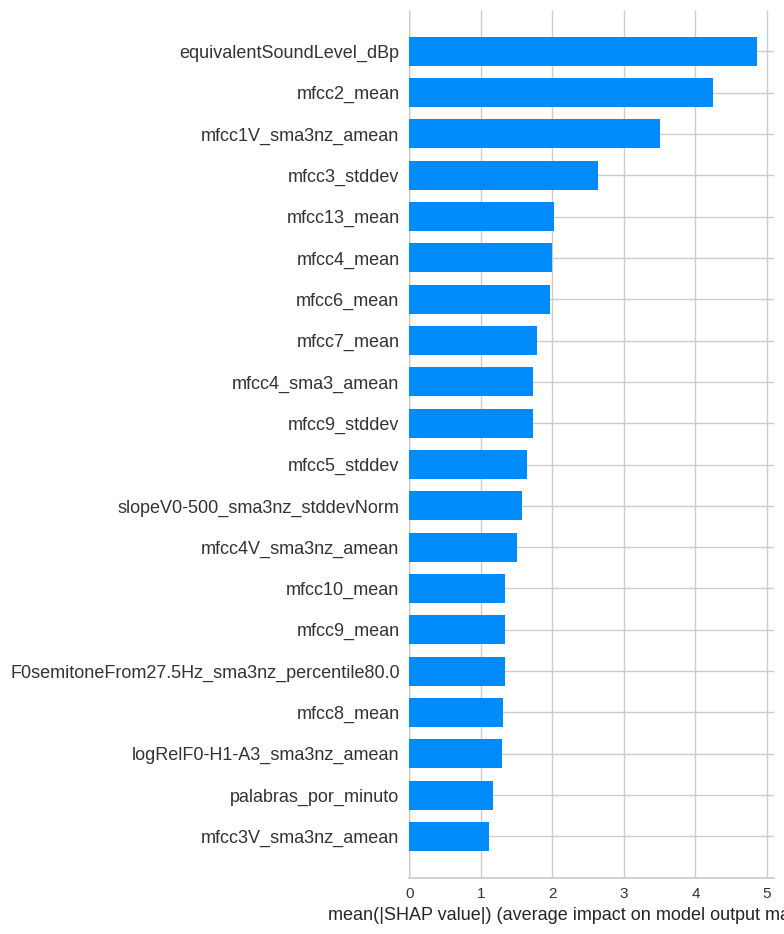

In [15]:
# 9) Interpretar modelo final (TOP K) con SHAP
lgbm_top = pipeline_top.named_steps["lgbm"]
explainer_top = shap.TreeExplainer(lgbm_top)

X_sample_top = X_tv_top.iloc[:500] if RETRAIN_WITH_VAL_TOP else X_train_top.iloc[:500]
shap_values_top = explainer_top.shap_values(X_sample_top)

# Feature importances nativa
if hasattr(lgbm_all, "feature_importances_"):
    importances_all = lgbm_all.feature_importances_
    features_all    = X_train.columns
    df_imp_all = pd.DataFrame({"feature": features_all, "importance": importances_all})
    df_imp_all.sort_values("importance", ascending=False, inplace=True)
    print("\n=== TOP 20 IMPORTANCIA (ALL features) ===")
    print(df_imp_all.head(20))

shap.summary_plot(shap_values_top, X_sample_top, plot_type="bar", show=True)

In [16]:
# 10) COMPARAR RESULTADOS
print("\n=== COMPARACIÓN ===")
print(f"Modelo ALL:  Test interno MAE={mae_test_all:.2f}, R2={r2_test_all:.2f};  Test externo MAE={mae_ext_all:.2f}, R2={r2_ext_all:.2f}")
print(f"Modelo TOP:  Test interno MAE={mae_test_top:.2f}, R2={r2_test_top:.2f};  Test externo MAE={mae_ext_top:.2f}, R2={r2_ext_top:.2f}")

print("""
Observa si el modelo con TOP K features (menos variables) mantiene rendimiento similar o mejor.
Si es parecido, has reducido dimensionalidad e incrementado interpretabilidad sin perder precisión.
""")


=== COMPARACIÓN ===
Modelo ALL:  Test interno MAE=11.65, R2=0.35;  Test externo MAE=12.63, R2=0.22
Modelo TOP:  Test interno MAE=8.75, R2=0.57;  Test externo MAE=14.21, R2=-0.07

Observa si el modelo con TOP K features (menos variables) mantiene rendimiento similar o mejor.
Si es parecido, has reducido dimensionalidad e incrementado interpretabilidad sin perder precisión.



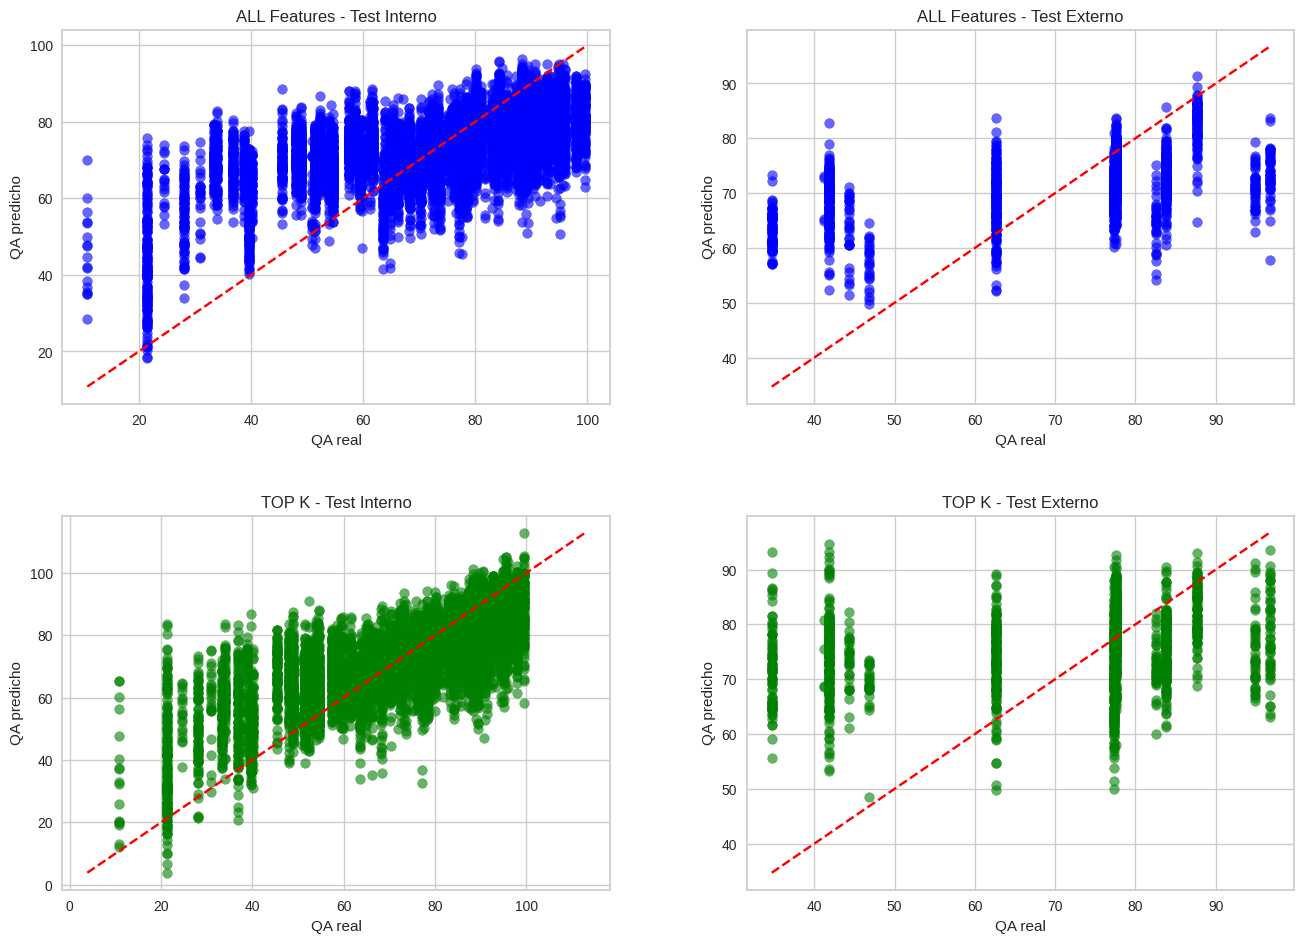

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Modelo ALL - Test Interno
axes[0, 0].scatter(y_test, y_pred_test_all, alpha=0.6, color='blue')
min_val = min(y_test.min(), y_pred_test_all.min())
max_val = max(y_test.max(), y_pred_test_all.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], '--', color='red')
axes[0, 0].set_xlabel("QA real")
axes[0, 0].set_ylabel("QA predicho")
axes[0, 0].set_title("ALL Features - Test Interno")
axes[0, 0].grid(True)

# 2) Modelo ALL - Test Externo
axes[0, 1].scatter(y_ext, y_pred_ext_all, alpha=0.6, color='blue')
min_val = min(y_ext.min(), y_pred_ext_all.min())
max_val = max(y_ext.max(), y_pred_ext_all.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], '--', color='red')
axes[0, 1].set_xlabel("QA real")
axes[0, 1].set_ylabel("QA predicho")
axes[0, 1].set_title("ALL Features - Test Externo")
axes[0, 1].grid(True)

# 3) Modelo TOP K - Test Interno
axes[1, 0].scatter(y_test_top, y_pred_test_top, alpha=0.6, color='green')
min_val = min(y_test_top.min(), y_pred_test_top.min())
max_val = max(y_test_top.max(), y_pred_test_top.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], '--', color='red')
axes[1, 0].set_xlabel("QA real")
axes[1, 0].set_ylabel("QA predicho")
axes[1, 0].set_title("TOP K - Test Interno")
axes[1, 0].grid(True)

# 4) Modelo TOP K - Test Externo
axes[1, 1].scatter(y_ext_top, y_pred_ext_top, alpha=0.6, color='green')
min_val = min(y_ext_top.min(), y_pred_ext_top.min())
max_val = max(y_ext_top.max(), y_pred_ext_top.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], '--', color='red')
axes[1, 1].set_xlabel("QA real")
axes[1, 1].set_ylabel("QA predicho")
axes[1, 1].set_title("TOP K - Test Externo")
axes[1, 1].grid(True)

# Ajustar los espacios entre subplots para que no queden muy pegados
plt.subplots_adjust(
    left=0.08,   # margen izquierdo
    right=0.96,  # margen derecho
    top=0.93,    # margen superior
    bottom=0.07, # margen inferior
    wspace=0.25, # espacio horizontal entre subplots
    hspace=0.3   # espacio vertical entre subplots
)

plt.show()